In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_20newsgroups

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.metrics import(
       accuracy_score,
        precision_score,
        recall_score,
        f1_score,
)




In [12]:
train_data = fetch_20newsgroups(
    subset="train",
    remove=("headers","footers","quotes")
)    
    

In [14]:
test_data = fetch_20newsgroups(
    subset="test",
    remove=("headers","footers","quotes")
)

In [18]:
X_train_test = train_data.data
y_train = train_data.target

X_test_text=test_data.data
y_test = test_data.target

class_names = train_data.target_names

In [25]:
print("Training documents :",len(X_train_test))
print("Testing documents :",len(X_test_text))
print("Number of classes:",len(class_names))

Training documents : 11314
Testing documents : 7532
Number of classes: 20


In [27]:
vectorizer = CountVectorizer(
    stop_words="english",
    min_df=2
)
X_train=vectorizer.fit_transform(X_train_test)
X_test=vectorizer.transform(X_test_text)

In [30]:
print("Training feature matrix:",X_train.shape)
print("Testing feature matrix:",X_test.shape)

Training feature matrix: (11314, 39115)
Testing feature matrix: (7532, 39115)


In [33]:
mnb=MultinomialNB()

mnb.fit(
    X_train,
    y_train
)

y_pred_mnb=mnb.predict(X_test)

In [38]:
binary_vectorizer = CountVectorizer(
    stop_words="english",
    min_df=2,
    binary=True
)

X_train_binary=binary_vectorizer.fit_transform(
    Xbnb = BernoulliNB()

bnb.fit(
    X_train_binary,
    y_train
)
y_pred_bnb = bnb.predict(
    X_test_binary
)    
_train_test
)
X_test_binary=binary_vectorizer.transform(
    X_test_text
)


In [43]:
bnb = BernoulliNB()

bnb.fit(
    X_train_binary,
    y_train
)
y_pred_bnb = bnb.predict(
    X_test_binary
)    


In [46]:
def evaluate(model_name, y_true, y_pred):
    print("\n",model_name,"\n")
    
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision :", precision_score(y_true, y_pred, average='weighted'))
    print("Recall :", recall_score(y_true, y_pred, average='weighted'))
    print("F1 Score :", f1_score(y_true, y_pred, average='weighted'))


In [48]:

evaluate("Multinomial Naive Bayes", y_test, y_pred_mnb)
evaluate("Bernoulli Naive Bayes", y_test, y_pred_bnb)


 Multinomial Naive Bayes 

Accuracy : 0.6510886882634095
Precision : 0.642532222238185
Recall : 0.6510886882634095
F1 Score : 0.6296441343359875

 Bernoulli Naive Bayes 

Accuracy : 0.4851301115241636
Precision : 0.6270343160004399
Recall : 0.4851301115241636
F1 Score : 0.4808387927958853


In [58]:
results=pd.DataFrame(columns=[
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
])

models=[
    ("MNB", mnb, y_pred_mnb),
    ("BNB", bnb, y_pred_bnb)
]

for name, model, pred in models:
    results.loc[len(results)]=[
        name,
        accuracy_score(y_test, pred),
        precision_score(y_test, pred,average='weighted'),
        recall_score(y_test, pred,average='weighted'),
        f1_score(y_test, pred,average='weighted'),
    ]
print(results) 

  Model  Accuracy  Precision    Recall  F1 Score
0   MNB  0.651089   0.642532  0.651089  0.629644
1   BNB  0.485130   0.627034  0.485130  0.480839


(array([0, 1]), [Text(0, 0, 'MNB'), Text(1, 0, 'BNB')])

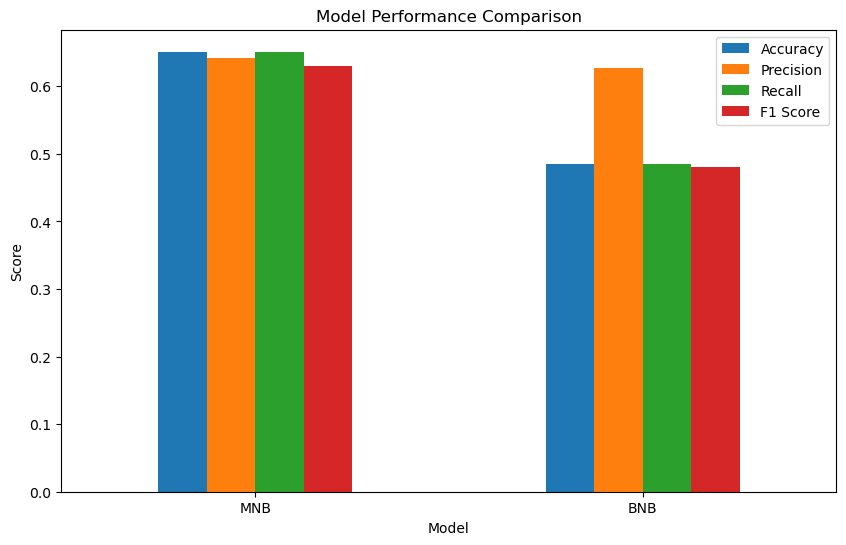

In [59]:
results.set_index('Model', inplace=True)
results.plot(kind='bar', figsize=(10, 6))
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)

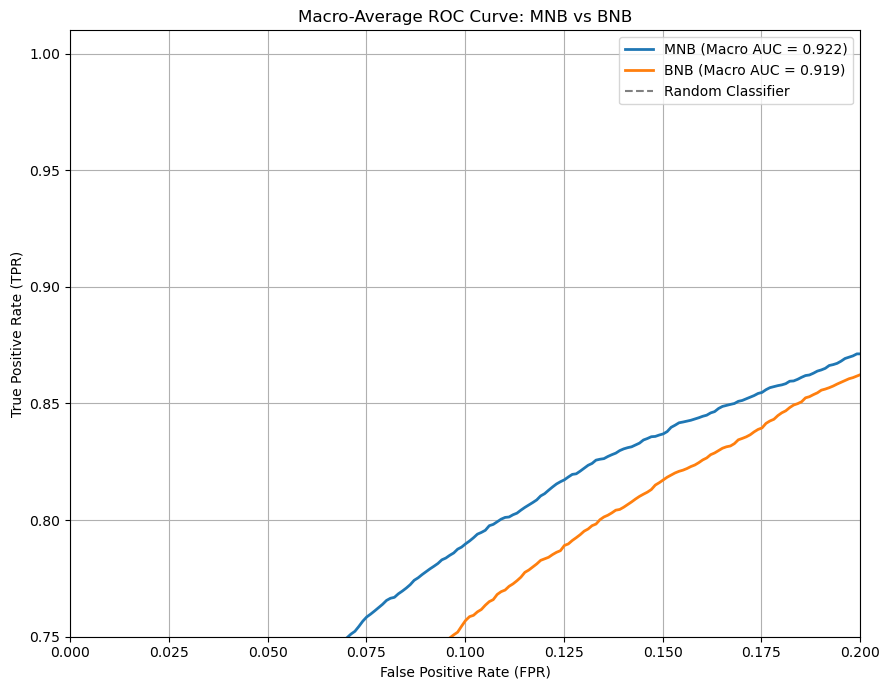

In [66]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(9, 7))

for name, model, pred in models:

    # Select the correct test matrix
    if name == "MNB":
        y_prob = model.predict_proba(X_test)
    else:
        y_prob = model.predict_proba(X_test_binary)

    # Store all class ROC curves
    all_fpr = np.linspace(0, 1, 1000)
    mean_tpr = np.zeros_like(all_fpr)

    for i in range(len(class_names)):

        y_true_class = (y_test == i).astype(int)

        fpr, tpr, thresholds = roc_curve(
            y_true_class,
            y_prob[:, i]
        )

        mean_tpr += np.interp(
            all_fpr,
            fpr,
            tpr
        )

    # Macro-average
    mean_tpr /= len(class_names)

    roc_auc = auc(
        all_fpr,
        mean_tpr
    )

    plt.plot(
        all_fpr,
        mean_tpr,
        linewidth=2,
        label=f"{name} (Macro AUC = {roc_auc:.3f})"
    )


# Random classifier
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Random Classifier"
)

plt.xlim(0, 0.2)
plt.ylim(0.75, 1.01)

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")

plt.title(
    "Macro-Average ROC Curve: MNB vs BNB"
)

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
